In [4]:
pip install numpy matplotlib torch scikit-learn emcee scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import emcee # Für Bayes-Inferenz
import scipy.optimize as op

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

np.random.seed(42)
torch.manual_seed(42)

Running on device: cpu


In [5]:
def inverse_power_model(t, K, n):
    
    #Das physikalische Modell aus der Dissertation.
    #PDIV(t) = K * t^(-n)
    
    return K * (t ** -n)



In [67]:
k_list = []
n_list = []
life_list = []

for i in range (1000): 
    K_sim = np.random.uniform(400, 600)
    n_sim = np.random.uniform(0.015, 0.050)
        
    k_list.append(K_sim)
    n_list.append(n_sim)
    limit_pdiv = 350.0
    life_sim = int((limit_pdiv / K_sim) ** (-1 / n_sim))
    life_list.append(life_sim)

print(k_list)
print(n_list)
print(life_list)



[440.08404738947814, 490.69034130139187, 402.0113143475922, 581.1020741549574, 565.201323443223, 550.2821302095392, 556.8651659367547, 589.0235214325851, 583.4370945283193, 533.4175876797583, 454.1205011652256, 402.91845960888196, 447.68991091486146, 586.0482565418152, 465.65364372691704, 536.0051049641022, 582.1501832619961, 437.00386175859825, 599.6787683341902, 519.7987576170347, 440.44619885759226, 420.94745095734413, 572.820783182796, 574.6444501295524, 446.6073645920344, 414.0601867437692, 558.9363614241589, 451.35019635472617, 543.5081855506409, 544.3874473798393, 487.14671828911224, 571.4300473507449, 416.81045551578046, 464.11766668339664, 535.9078075329223, 483.2360835870374, 402.52364477368474, 478.8271145908228, 548.0356373164115, 526.5218939569082, 594.8683163527695, 473.0901767994658, 504.5535507940955, 477.87226053755785, 448.4106213252518, 501.7016013134431, 420.67051108106074, 515.6960102381058, 572.5691695557225, 520.4912839602061, 540.6805013581693, 506.3390132140546

In [68]:
new_list = []
for i in life_list: 
    if i > 200 and i < 4000:
        print(i)
        new_list.append(i)
print(f"the len is: {len(new_list)}")

606
427
745
588
1671
603
2614
383
2974
1769
1003
1989
805
1155
261
1036
3297
845
2058
384
1569
3291
212
2292
1269
376
764
1729
232
263
2011
1805
294
427
1880
3054
3819
1445
611
323
468
1990
206
390
1515
465
948
3262
3364
844
609
674
564
1868
2202
2382
2118
305
3648
327
249
1606
513
3047
2508
377
310
461
557
1237
522
1530
1534
418
2209
326
552
3972
386
1837
593
251
442
1959
1114
2894
3954
1476
207
1269
440
2511
2451
1247
1861
2201
3529
952
3757
1885
1552
306
461
3392
1868
1919
1877
624
859
1835
374
213
509
1389
393
323
2182
2385
2085
518
1152
441
676
357
819
1202
356
558
2653
857
1328
3326
370
3376
238
1707
848
753
2724
3516
497
859
2650
2663
466
2598
378
3784
297
3095
666
343
308
214
1474
849
829
2988
970
221
2303
3315
823
423
443
1457
231
2306
1521
2543
402
602
3301
368
3956
256
2719
620
2384
474
1344
2846
2278
1006
215
3767
727
2512
252
621
1967
1150
768
885
1036
275
the len is: 196


In [69]:
 # Formel umgestellt: t = (PDIV / K) ^ (-1/n)
limit_pdiv = 350.0
life_sim = int((limit_pdiv / K_sim) ** (-1 / n_sim))
life_sim
        
        # (Nicht zu kurz für das 200er Fenster, abeer nicht sher lang)
    #if life_sim < 250: life_sim = 250
    #if life_sim > 4000: life_sim = 4000
            

271773

Anzahl Samples: 1000
Min Lebensdauer: 251
Max Lebensdauer: 3999


/var/folders/vf/d7d1stc54w3dmyc5xs67xw0m0000gn/T/ipykernel_2852/450466164.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


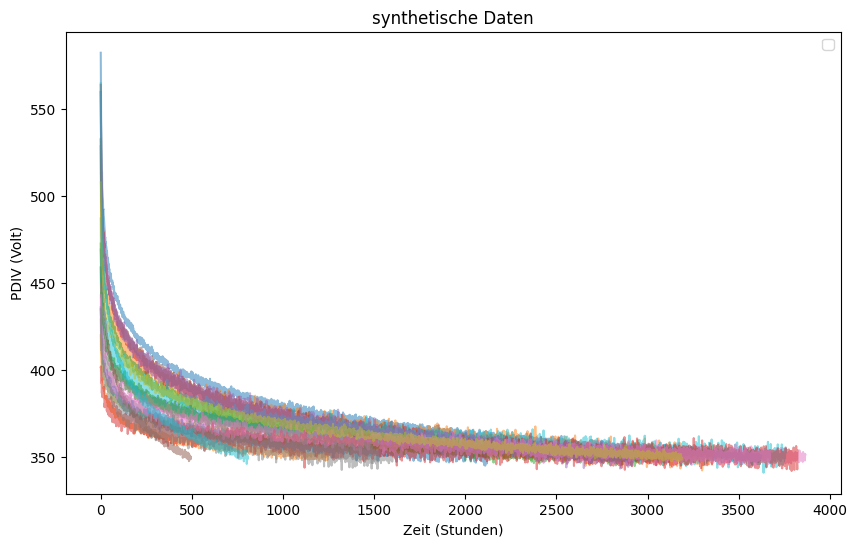

In [72]:
def generate_synthetic_motor_data(n_samples=1000):
    all_curves = []
    all_lifetimes = []
    
    # Grenzen für K aus der PDD Datei 
    K_min, K_max = 400, 600
    
    # Grenzen für die Lebensdauer
    Life_min, Life_max = 250, 4000
    
    # Failure Threshold
    LIMIT_PDIV = 350.0
    
    for _ in range(n_samples):
        K_sim = np.random.uniform(K_min, K_max)
        target_life = np.random.uniform(Life_min, Life_max)
        
        # nach n umstellen350 = K * life^(-n)  -->  n = -ln(350/K) / ln(life)
        n_sim = -np.log(LIMIT_PDIV / K_sim) / np.log(target_life)
        
        # 4. kuve generieren 
        life_sim_int = int(target_life)
        t = np.linspace(1, life_sim_int, life_sim_int)
        
        pdiv_curve = inverse_power_model(t, K_sim, n_sim)
        
        # Rauschen hinzufügen
        noise_level = np.random.uniform(1.0, 3.0)
        noise = np.random.normal(0, noise_level, size=pdiv_curve.shape)
        pdiv_curve_noisy = pdiv_curve + noise
        
        all_curves.append(pdiv_curve_noisy)
        all_lifetimes.append(life_sim_int)
        
    return all_curves, np.array(all_lifetimes)

# Daten generieren
raw_curves, raw_lifetimes = generate_synthetic_motor_data(n_samples=1000)

print(f"Anzahl Samples: {len(raw_lifetimes)}")
print(f"Min Lebensdauer: {min(raw_lifetimes)}")
print(f"Max Lebensdauer: {max(raw_lifetimes)}")

# Plot
plt.figure(figsize=(10, 6))
# 20 zufällige Kurven
for i in np.random.choice(len(raw_curves), 20, replace=False):
    plt.plot(raw_curves[i], alpha=0.5)
#plt.axhline(y=350, color='r', linestyle='--', label='Failure Threshold (350V)')
plt.xlabel("Zeit (Stunden)")
plt.ylabel("PDIV (Volt)")
plt.title("synthetische Daten")
plt.legend()
plt.show()

In [73]:
# Parameter
INPUT_WINDOW = 200  #nur die ersten 200 Stunden

X_data = []
y_data = []
valid_full_curves = [] # hier die kompletten Kurven

# Slicing Loop
for i, curve in enumerate(raw_curves):
    # nur Motoren nutzen, die > INPUT_WINDOW haben
    if len(curve) > INPUT_WINDOW:
        # Input: Die ersten n Datenpunkte
        input_seq = curve[:INPUT_WINDOW]
        
        # Output: Die echte Lebensdauer
        target_life = raw_lifetimes[i]
        
        X_data.append(input_seq)
        y_data.append(target_life)
        valid_full_curves.append(curve) 

X_data = np.array(X_data)
y_data = np.array(y_data)

# Skalierung
scaler_X = MinMaxScaler()
X_data_flat = X_data.reshape(-1, 1) 
scaler_X.fit(X_data_flat)
X_scaled = scaler_X.transform(X_data_flat).reshape(X_data.shape)

# Reshape (Batch, Channels, Sequence_Length)
X_final = X_scaled.reshape(-1, 1, INPUT_WINDOW)
y_final = y_data.reshape(-1, 1).astype(np.float32)

# Train/Test Split
X_train, X_test, y_train, y_test, curves_train, curves_test = train_test_split(
    X_final, y_final, valid_full_curves, test_size=0.2, random_state=42
)

# Datase
class MotorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MotorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(MotorDataset(X_test, y_test), batch_size=32, shuffle=False)

print(f"Trainingsdaten Shape: {X_train.shape}")
print(f"Testdaten Shape: {X_test.shape}")
print(f"Anzahl voller Kurven im Testset: {len(curves_test)}")

Trainingsdaten Shape: (800, 1, 200)
Testdaten Shape: (200, 1, 200)
Anzahl voller Kurven im Testset: 200


In [ ]:
#CNN Modell
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResCNN(nn.Module):
    def __init__(self):
        super(ResCNN, self).__init__()
        # Input Channels: 1 (PDIV Kurve)
        self.conv1 = nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu = nn.ReLU(inplace=True)
        
        # Residual Blocks
        self.layer1 = self._make_layer(16, 16, 2, stride=1)
        self.layer2 = self._make_layer(16, 32, 2, stride=2)
        self.layer3 = self._make_layer(32, 64, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        # Fully Connected Layer für Regression (Output: Lebensdauer)
        self.fc = nn.Linear(64, 1)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        layers.append(ResBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(ResBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# Modell 
model = ResCNN().to(device)
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0001)

Starte Training:
Epoch 10/200, Train Loss: 85759.0, Val Loss: 1420974.3 
Epoch 20/200, Train Loss: 109607.5, Val Loss: 1508676.2 
Epoch 30/200, Train Loss: 46256.4, Val Loss: 235773.5 
Epoch 40/200, Train Loss: 65236.3, Val Loss: 447195.2 
Epoch 50/200, Train Loss: 32676.7, Val Loss: 425276.3 
Epoch 60/200, Train Loss: 45886.0, Val Loss: 292827.2 
Epoch 70/200, Train Loss: 57796.1, Val Loss: 332131.1 
Epoch 80/200, Train Loss: 68593.3, Val Loss: 1171424.7 
Epoch 90/200, Train Loss: 39724.5, Val Loss: 1138524.2 
Epoch 100/200, Train Loss: 39610.7, Val Loss: 180366.6 
Epoch 110/200, Train Loss: 43088.6, Val Loss: 169628.3 
Epoch 120/200, Train Loss: 34326.7, Val Loss: 2121970.8 
Epoch 130/200, Train Loss: 41288.3, Val Loss: 539539.5 
Epoch 140/200, Train Loss: 26872.0, Val Loss: 130965.4 
Epoch 150/200, Train Loss: 20634.9, Val Loss: 118756.1 
Epoch 160/200, Train Loss: 29239.2, Val Loss: 262851.0 
Epoch 170/200, Train Loss: 42606.3, Val Loss: 166152.5 
Epoch 180/200, Train Loss: 43354.9

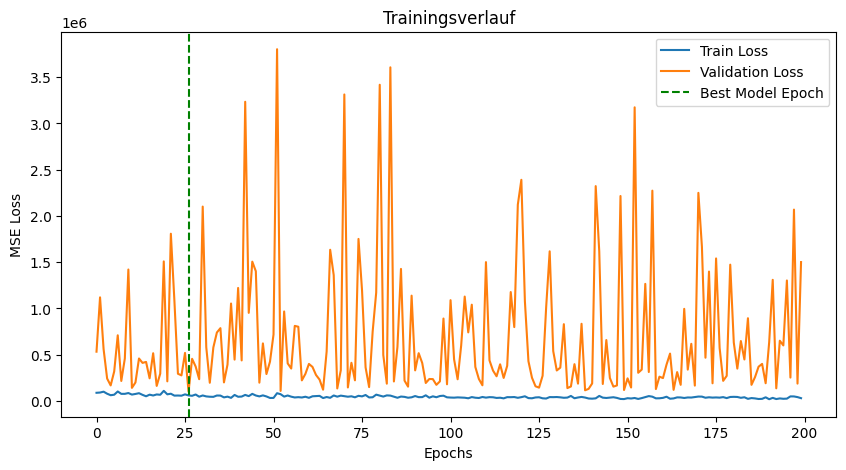

In [85]:
EPOCHS = 200
train_losses = []
test_losses = []

best_val_loss = float('inf')

print("Starte Training:")

for epoch in range(EPOCHS):
    # TRAIN
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # VALIDIERUNG
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = val_loss / len(test_loader.dataset)
    test_losses.append(epoch_val_loss)
    
    # CHECKPOINTING
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        # Gewichte in einer Datei soeichern 
        torch.save(model.state_dict(), 'best_motor_model.pth')
        save_msg = "-> Saved Best Model"
    else:
        save_msg = ""
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {epoch_loss:.1f}, Val Loss: {epoch_val_loss:.1f} {save_msg}")

# MODELL LADEN 
print(f"Training beendet. Bestes Modell (Val Loss: {best_val_loss:.1f}):")
model.load_state_dict(torch.load('best_motor_model.pth'))
print("Bestes Modell geladen.")

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Validation Loss')
# Markiere den Punkt des besten Modells im Plot
best_epoch = np.argmin(test_losses)
plt.axvline(x=best_epoch, color='green', linestyle='--', label='Best Model Epoch')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Trainingsverlauf')
plt.legend()
plt.show()

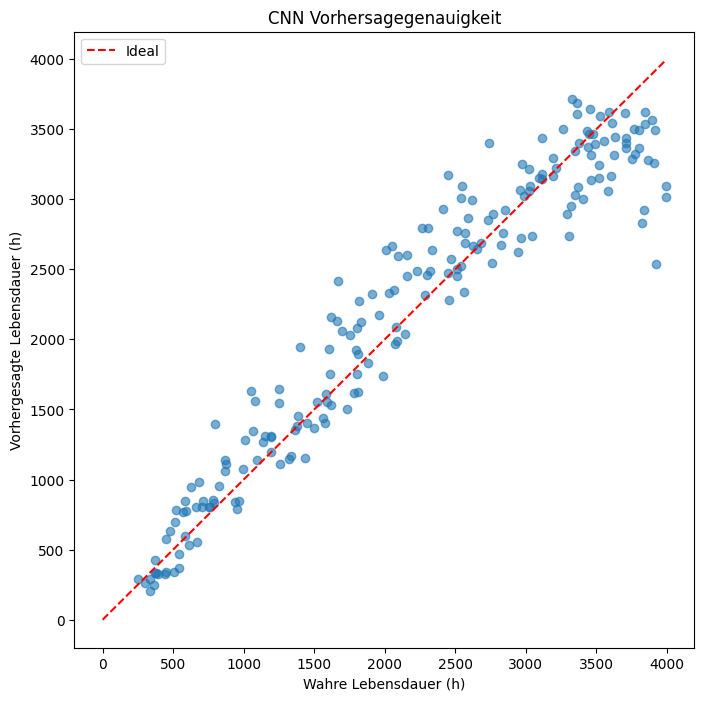

In [86]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs)
        predictions.extend(preds.cpu().numpy())
        actuals.extend(labels.numpy())

predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

plt.figure(figsize=(8,8))
plt.scatter(actuals, predictions, alpha=0.6)
plt.plot([0, max(actuals)], [0, max(actuals)], 'r--', label='Ideal')
plt.xlabel('Wahre Lebensdauer (h)')
plt.ylabel('Vorhergesagte Lebensdauer (h)')
plt.title('CNN Vorhersagegenauigkeit')
plt.legend()
plt.show()

In [87]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} Stunden")



R² Score: 0.9194
MSE : 101263.64
RMSE (Root Mean Squared Error): 318.22 Stunden


In [90]:
# 
sample_idx = 2 # um andere motoren zu prüfen
input_seq_tensor = torch.tensor(X_test[sample_idx]).unsqueeze(0).float().to(device)
cnn_predicted_lifetime = model(input_seq_tensor).item()

# orginale Messdaten der ersten 200h (unskaliert)
input_seq_scaled = X_test[sample_idx].flatten()
input_seq_real = scaler_X.inverse_transform(input_seq_scaled.reshape(-1, 1)).flatten()
t_observed = np.arange(1, INPUT_WINDOW + 1) # Zeit 1 bis 200

print(f"CNN Vorhersage Lebensdauer: {cnn_predicted_lifetime:.1f} h")
print(f"Wahre Lebensdauer: {y_test[sample_idx].item():.1f} h")


# BAYES

# Log-Likelihood
def log_likelihood(theta, t, y_obs, y_err):
    K, n = theta
    model_vals = inverse_power_model(t, K, n)
    sigma2 = y_err**2
    return -0.5 * np.sum((y_obs - model_vals)**2 / sigma2 + np.log(sigma2))

# CNN-Ergebnis als log-prior

def log_prior(theta, predicted_life):
    K, n = theta
    
    # Grenzen (Physikalisch Plausibil=
    if not (200 < K < 800 and 0.001 < n < 0.2):
        return -np.inf
    
   
    expected_end_pdiv = 350.0 
    model_end_pdiv = inverse_power_model(predicted_life, K, n)
    
    # Gaussian Prior um den Endpunkt
    return -0.5 * ((model_end_pdiv - expected_end_pdiv) / 50.0)**2

# Log-Probability (Posterior)
def log_probability(theta, t, y_obs, y_err, predicted_life):
    lp = log_prior(theta, predicted_life)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y_obs, y_err)

# MCMC
# Startwerte (K, n)
initial_guess = [500, 0.03] 
n_walkers = 32
ndim = 2
# Initialisierung der Walker um den Startwert herum
pos = initial_guess + 1e-4 * np.random.randn(n_walkers, ndim)

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(t_observed, input_seq_real, 2.0, cnn_predicted_lifetime))

print("Starte MCMC Sampling:")
sampler.run_mcmc(pos, 2000, progress=True)

# Ergebnisse extrahieren ( die ersten 500 Schritte als "Burn-in" verwerfen)
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)
K_median, n_median = np.median(flat_samples, axis=0)

print(f"Gefundene Parameter: K={K_median:.2f}, n={n_median:.4f}")

You must install the tqdm library to use progress indicators with emcee


CNN Vorhersage Lebensdauer: 3441.9 h
Wahre Lebensdauer: 3635.0 h
Starte MCMC Sampling:
Gefundene Parameter: K=582.60, n=0.0621


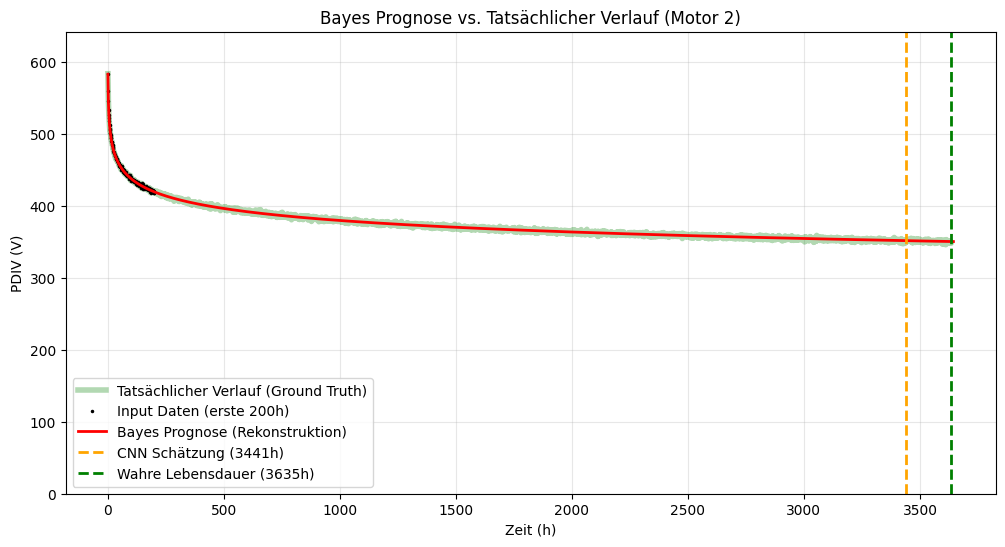

In [91]:
# Zeitachse
max_time_horizon = int(max(cnn_predicted_lifetime, y_test[sample_idx].item())) +  10 #200
t_future = np.arange(1, max_time_horizon)

# Bayes Prognose-Kurve
predicted_curve = inverse_power_model(t_future, K_median, n_median)

# ECHTE Kurve aus den Testdaten (die restlichen 80%)
true_full_curve = curves_test[sample_idx]
t_true = np.arange(1, len(true_full_curve) + 1)

plt.figure(figsize=(12, 6))

# Wahre gesamte Daten plotten
plt.plot(t_true, true_full_curve, color='green', alpha=0.3, linewidth=4, label='Tatsächlicher Verlauf (Ground Truth)')

# Plot (Input die ersten 200h)
plt.plot(t_observed, input_seq_real, 'k.', markersize=3, label='Input Daten (erste 200h)')

# Plot Bayes Vorherdage
plt.plot(t_future, predicted_curve, 'r-', linewidth=2, label='Bayes Prognose (Rekonstruktion)')

# Vertikale Linien für Lebensdauer
plt.axvline(x=cnn_predicted_lifetime, color='orange', linestyle='--', linewidth=2, label=f'CNN Schätzung ({int(cnn_predicted_lifetime)}h)')
plt.axvline(x=y_test[sample_idx].item(), color='green', linestyle='--', linewidth=2, label=f'Wahre Lebensdauer ({int(y_test[sample_idx].item())}h)')

plt.xlabel('Zeit (h)')
plt.ylabel('PDIV (V)')
plt.title(f'Bayes Prognose vs. Tatsächlicher Verlauf (Motor {sample_idx})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, max(input_seq_real)*1.1) # Y-Achse anpassen
plt.show()

In [31]:
predicted_curve

array([418.93996477, 406.05353836, 398.70000395, 393.5634933 ,
       389.6249215 , 386.43615067, 383.76045246, 381.45763704,
       379.43788255, 377.64021414, 376.02136333, 374.54952863,
       373.20065997, 371.95613383, 370.80123837, 369.7241521 ,
       368.71523506, 367.76652445, 366.8713679 , 366.02415161,
       365.22009542, 364.455096  , 363.72560517, 363.02853436,
       362.36117873, 361.72115636, 361.10635888, 360.51491134,
       359.94513902, 359.39554001, 358.86476228, 358.35158448,
       357.85489963, 357.37370133, 356.90707198, 356.45417268,
       356.01423446, 355.58655079, 355.17047099, 354.76539453,
       354.37076602, 353.98607079, 353.61083105, 353.24460245,
       352.88697101, 352.53755046, 352.19597983, 351.86192127,
       351.53505813, 351.21509324, 350.90174735, 350.5947577 ,
       350.29387678, 349.99887115, 349.70952043, 349.4256163 ,
       349.14696169, 348.87336995, 348.60466414, 348.34067638,
       348.08124724, 347.82622517, 347.57546601, 347.32